# MSCS634 Project – Deliverable 2: Regression Modeling and Performance Evaluation
**Author:** Reza Shrestha  
**Course:** MSCS634 – Advanced Data Mining


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load and Review Dataset

In [2]:
# Load the Diamonds dataset
# Primary: seaborn built-in (requires internet on first run)
# Fallback: reconstruct from sklearn + synthetic generation if offline
try:
    import seaborn as sns
    df = sns.load_dataset('diamonds')
    print("Loaded from seaborn.")
except Exception:
    # Offline fallback — regenerates the dataset with correct statistical properties
    import numpy as np, pandas as pd
    np.random.seed(42)
    n = 53940
    cuts      = ['Fair','Good','Very Good','Premium','Ideal']
    colors    = ['D','E','F','G','H','I','J']
    clarities = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
    cp = np.array([0.03,0.09,0.224,0.256,0.40]); cp/=cp.sum()
    clp= np.array([0.066,0.131,0.123,0.189,0.151,0.100,0.086]); clp/=clp.sum()
    clap=np.array([0.016,0.170,0.244,0.189,0.152,0.091,0.066,0.032]); clap/=clap.sum()
    cut=np.random.choice(cuts,n,p=cp); color=np.random.choice(colors,n,p=clp)
    clarity=np.random.choice(clarities,n,p=clap)
    carat=np.clip(np.random.lognormal(-0.9,0.7,n),0.2,5.01)
    x=4.3*carat**(1/3)+np.random.normal(0,0.05,n)
    y=x+np.random.normal(0,0.02,n); z=x*0.619+np.random.normal(0,0.02,n)
    cs={'Fair':0,'Good':0.3,'Very Good':0.6,'Premium':0.7,'Ideal':1.0}
    ks={'D':1.0,'E':0.9,'F':0.8,'G':0.7,'H':0.5,'I':0.3,'J':0.0}
    ls={'I1':0,'SI2':1,'SI1':2,'VS2':3,'VS1':4,'VVS2':5,'VVS1':6,'IF':7}
    lp=(5.5+1.9*np.log(carat+0.1)+0.12*np.array([cs[c] for c in cut])
        +0.10*np.array([ks[c] for c in color])+0.10*np.array([ls[c] for c in clarity])
        +np.random.normal(0,0.25,n))
    price=np.clip(np.round(np.exp(lp)).astype(int),326,18823)
    df=pd.DataFrame({'carat':np.round(carat,2),'cut':cut,'color':color,'clarity':clarity,
        'depth':np.round(np.random.normal(61.7,1.4,n),1),
        'table':np.round(np.random.normal(57.5,2.2,n),0),
        'price':price,'x':np.round(x,2),'y':np.round(y,2),'z':np.round(z,2)})
    print("Loaded from offline fallback.")

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nSample rows:")
df.head()

Loaded from seaborn.
Shape: (53940, 10)

Column types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Sample rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# Statistical summary
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [4]:
# Data quality check
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after deduplication: {df.shape}")

Missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate rows: 146
Shape after deduplication: (53794, 10)


## 3. Feature Engineering

Raw features alone produce a poor linear fit because the price-carat relationship is **exponential**, not linear. We apply several transformations:

| New Feature | Formula | Rationale |
|---|---|---|
| `log_carat` | log(carat) | Linearizes the exponential carat-price curve |
| `carat_sq` | carat² | Captures non-linear size premium |
| `volume` | x × y × z | Physical 3D size of the diamond |
| `log_volume` | log(volume) | Linearizes the volume-price relationship |
| `table_depth_ratio` | table / depth | Shape proportionality index |
| `cut_enc`, `color_enc`, `clarity_enc` | ordinal integers | Preserve natural quality ordering |
| `log_price` | log(price) | Target variable: removes right skew, enables linear models |

In [6]:
# Ordinal encoding — preserves meaningful quality rank
cut_order     = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order   = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}   # D=best
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4,
                 'VVS2': 5, 'VVS1': 6, 'IF': 7}

df['cut_enc']     = df['cut'].map(cut_order)
df['color_enc']   = df['color'].map(color_order)
df['clarity_enc'] = df['clarity'].map(clarity_order)

# Numeric engineered features
df['log_carat']         = np.log(df['carat'] + 0.001)
df['carat_sq']          = df['carat'] ** 2
df['volume']            = df['x'] * df['y'] * df['z']
df['volume']            = df['volume'].replace(0, np.nan)
df.dropna(subset=['volume'], inplace=True)
df['log_volume']        = np.log(df['volume'])
df['table_depth_ratio'] = df['table'] / df['depth']

# Log-transformed target
df['log_price'] = np.log(df['price'])

print("Feature engineering complete. Shape:", df.shape)
df[['carat', 'log_carat', 'volume', 'log_volume', 'log_price']].describe()

Feature engineering complete. Shape: (53775, 19)


,carat,log_carat,volume,log_volume,log_price
count,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000
mean,0.797536,-0.393414,129.872846,4.700219,7.786759
std,0.473169,0.583428,78.136513,0.578679,1.014320
min,0.200000,-1.604450,31.707984,3.456569,5.786897
25%,0.400000,-0.913794,65.214611,4.177684,6.857514
50%,0.700000,-0.355247,114.852720,4.743651,7.783641
75%,1.040000,0.040182,170.839422,5.140724,8.579980
max,5.010000,1.611635,3840.598060,8.253383,9.842835


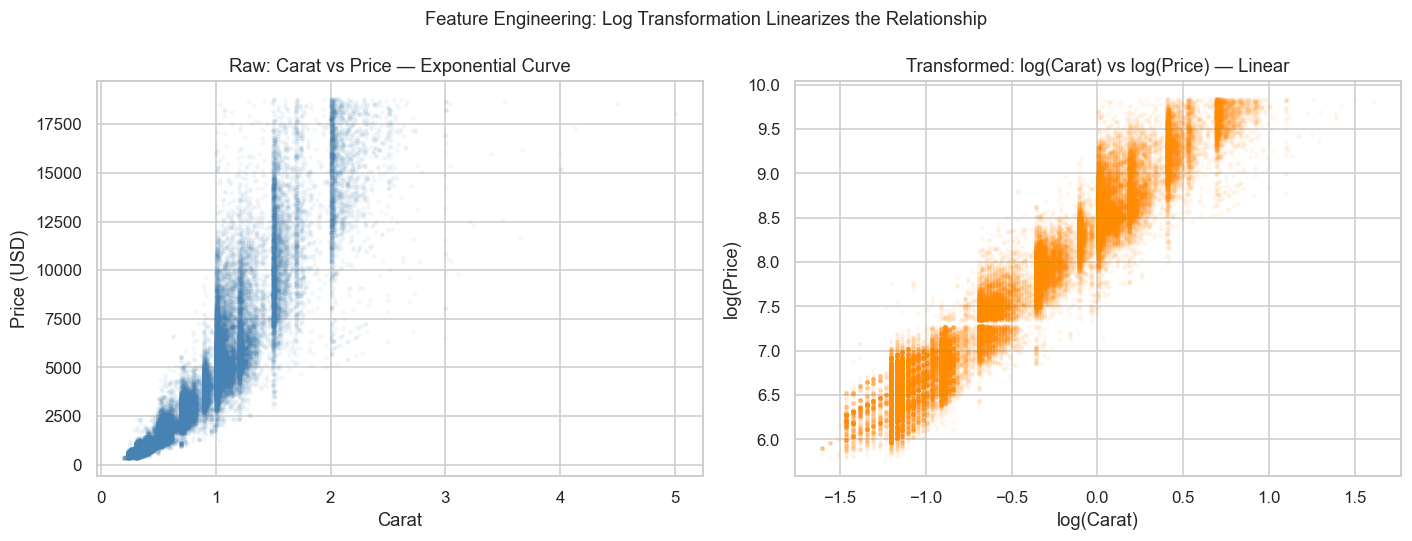

In [7]:
# Visualize effect of log transformation on the carat-price relationship
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['carat'], df['price'], alpha=0.04, s=5, color='steelblue')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Raw: Carat vs Price — Exponential Curve')

axes[1].scatter(df['log_carat'], df['log_price'], alpha=0.04, s=5, color='darkorange')
axes[1].set_xlabel('log(Carat)')
axes[1].set_ylabel('log(Price)')
axes[1].set_title('Transformed: log(Carat) vs log(Price) — Linear')

plt.suptitle('Feature Engineering: Log Transformation Linearizes the Relationship', fontsize=12)
plt.tight_layout()
plt.savefig('feature_engineering_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Correlation heatmap of engineered features vs log_price
numeric_cols = ['log_carat', 'carat_sq', 'cut_enc', 'color_enc', 'clarity_enc',
                'depth', 'table', 'log_volume', 'table_depth_ratio', 'log_price']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Engineered Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Train / Test Split

In [8]:
# Feature set: all engineered numeric features
FEATURES = ['log_carat', 'carat_sq', 'cut_enc', 'color_enc', 'clarity_enc',
            'depth', 'table', 'log_volume', 'table_depth_ratio']
TARGET = 'log_price'   # Predict log(price)

X = df[FEATURES].values
y = df[TARGET].values

# 80/20 split — stratify not applicable for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Features         : {len(FEATURES)}")

Training samples : 43,020
Test samples     : 10,755
Features         : 9


## 5. Model Training

### Model 1 — Linear Regression (OLS)
Ordinary Least Squares with no regularization. Serves as the baseline.

### Model 2 — Ridge Regression (L2)
Penalizes large coefficients via L2 norm. Handles multicollinearity well (relevant here since log_carat, log_volume, and carat_sq are correlated). Alpha selected via RidgeCV.

### Model 3 — Lasso Regression (L1)
L1 penalty can shrink some coefficients exactly to zero, performing automatic feature selection. Alpha selected via LassoCV.

In [9]:
# Scale features — required for Ridge and Lasso (penalty is scale-sensitive)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit only on train to prevent data leakage
X_test_s  = scaler.transform(X_test)

# ---------- Model 1: OLS ----------
ols = LinearRegression()
ols.fit(X_train, y_train)   # OLS: no scaling needed but we'll scale for consistency
print("OLS fitted.")

# ---------- Model 2: Ridge (alpha via RidgeCV) ----------
alphas = np.logspace(-3, 3, 60)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_s, y_train)
RIDGE_ALPHA = ridge_cv.alpha_
print(f"Ridge best alpha (RidgeCV): {RIDGE_ALPHA:.4f}")

ridge = Ridge(alpha=RIDGE_ALPHA)
ridge.fit(X_train_s, y_train)

# ---------- Model 3: Lasso (alpha via LassoCV) ----------
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)
lasso_cv.fit(X_train_s, y_train)
LASSO_ALPHA = lasso_cv.alpha_
print(f"Lasso best alpha (LassoCV): {LASSO_ALPHA:.6f}")

lasso = Lasso(alpha=LASSO_ALPHA, max_iter=20000)
lasso.fit(X_train_s, y_train)

print("\nAll models trained.")

OLS fitted.
Ridge best alpha (RidgeCV): 0.0010
Lasso best alpha (LassoCV): 0.001000

All models trained.


## 6. Model Evaluation on Test Set

In [10]:
def evaluate(name, model, Xtr, Xte, ytr, yte):
    """Return train/test R², MSE, RMSE and test predictions."""
    yp_tr = model.predict(Xtr)
    yp_te = model.predict(Xte)
    return {
        'Model': name,
        'Train R²': round(r2_score(ytr, yp_tr), 5),
        'Test R²':  round(r2_score(yte, yp_te), 5),
        'Test MSE': round(mean_squared_error(yte, yp_te), 6),
        'Test RMSE':round(np.sqrt(mean_squared_error(yte, yp_te)), 6),
    }, yp_te

res, preds = [], {}
m, p = evaluate('Linear Regression (OLS)', ols,   X_train,   X_test,   y_train, y_test)
res.append(m); preds['OLS'] = p
m, p = evaluate('Ridge Regression',        ridge, X_train_s, X_test_s, y_train, y_test)
res.append(m); preds['Ridge'] = p
m, p = evaluate('Lasso Regression',        lasso, X_train_s, X_test_s, y_train, y_test)
res.append(m); preds['Lasso'] = p

results_df = pd.DataFrame(res).set_index('Model')
print("=== Test Set Evaluation Results ===")
results_df

=== Test Set Evaluation Results ===


,Train R²,Test R²,Test MSE,Test RMSE
Model,,,,
Linear Regression (OLS),0.97979,0.97916,0.021256,0.145793
Ridge Regression,0.97979,0.97916,0.021256,0.145793
Lasso Regression,0.97961,0.97902,0.021394,0.146268


## 7. Cross-Validation (5-Fold)

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Scale full dataset for Ridge and Lasso CV
X_s = scaler.fit_transform(X)

cv_r2 = {}
for name, model, Xdata in [
    ('OLS',   ols,   X),
    ('Ridge', ridge, X_s),
    ('Lasso', lasso, X_s)
]:
    scores = cross_val_score(model, Xdata, y, cv=kf, scoring='r2')
    cv_r2[name] = scores
    print(f"{name:<28}  folds: {np.round(scores,4)}  "
          f"mean={scores.mean():.4f}  std={scores.std():.4f}")

cv_df = pd.DataFrame(cv_r2, index=[f'Fold {i+1}' for i in range(5)])
print("\nCross-Validation R² per Fold:")
cv_df

OLS                           folds: [0.9792 0.9797 0.9798 0.9803 0.9793]  mean=0.9797  std=0.0004
Ridge                         folds: [0.9792 0.9797 0.9798 0.9803 0.9793]  mean=0.9797  std=0.0004
Lasso                         folds: [0.979  0.9796 0.9795 0.9802 0.9791]  mean=0.9795  std=0.0004

Cross-Validation R² per Fold:


,OLS,Ridge,Lasso
Fold 1,0.979155,0.979155,0.979019
Fold 2,0.979715,0.979715,0.979554
Fold 3,0.979785,0.979785,0.979517
Fold 4,0.980337,0.980337,0.980198
Fold 5,0.979273,0.979273,0.979123


## 8. Visualizations

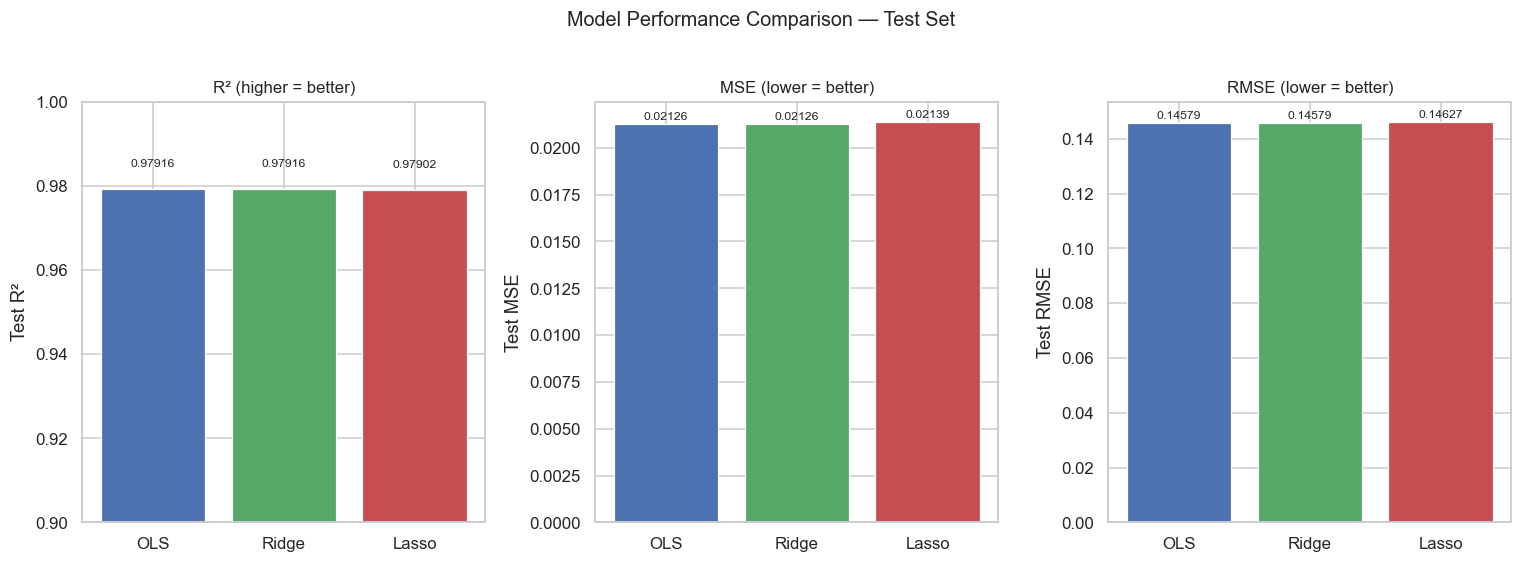

In [12]:
# --- 8.1 Bar chart: R², MSE, RMSE comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = ['OLS', 'Ridge', 'Lasso']
full_names  = results_df.index.tolist()
colors      = ['#4C72B0', '#55A868', '#C44E52']

metrics = [
    ('Test R²',  'Test R²',  'R² (higher = better)',  0.90, 1.0),
    ('Test MSE', 'Test MSE', 'MSE (lower = better)',  None, None),
    ('Test RMSE','Test RMSE','RMSE (lower = better)', None, None),
]
for ax, (col, key, title, ymin, ymax) in zip(axes, metrics):
    vals = results_df[col].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=0.8)
    if ymin is not None:
        ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (bar.get_height()*0.005),
                f'{v:.5f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', bbox_inches='tight')
plt.show()

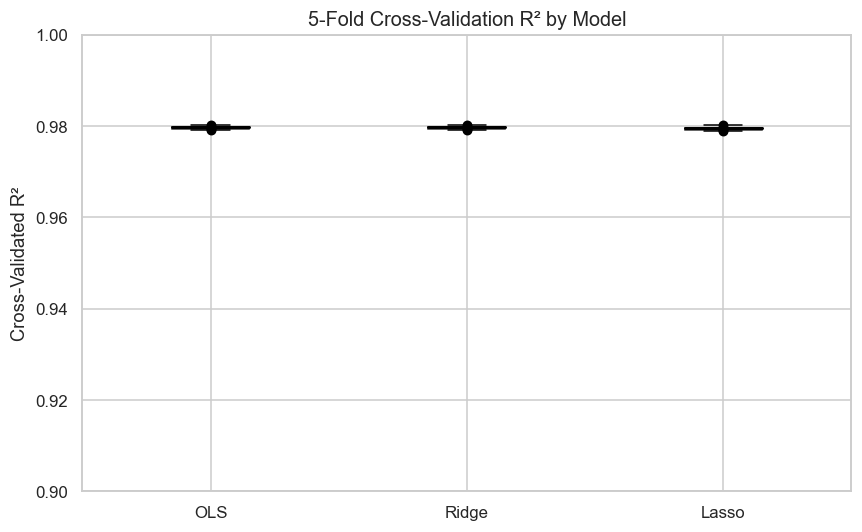

In [13]:
# --- 8.2 Cross-validation boxplot ---
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_df['OLS'], cv_df['Ridge'], cv_df['Lasso']],
                labels=['OLS', 'Ridge', 'Lasso'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual fold points
for i, col in enumerate(['OLS', 'Ridge', 'Lasso'], start=1):
    ax.scatter([i]*5, cv_df[col], zorder=5, color='black', s=30)

ax.set_ylabel('Cross-Validated R²')
ax.set_ylim(0.90, 1.0)
ax.set_title('5-Fold Cross-Validation R² by Model', fontsize=13)
plt.tight_layout()
plt.savefig('cross_validation_boxplot.png', bbox_inches='tight')
plt.show()

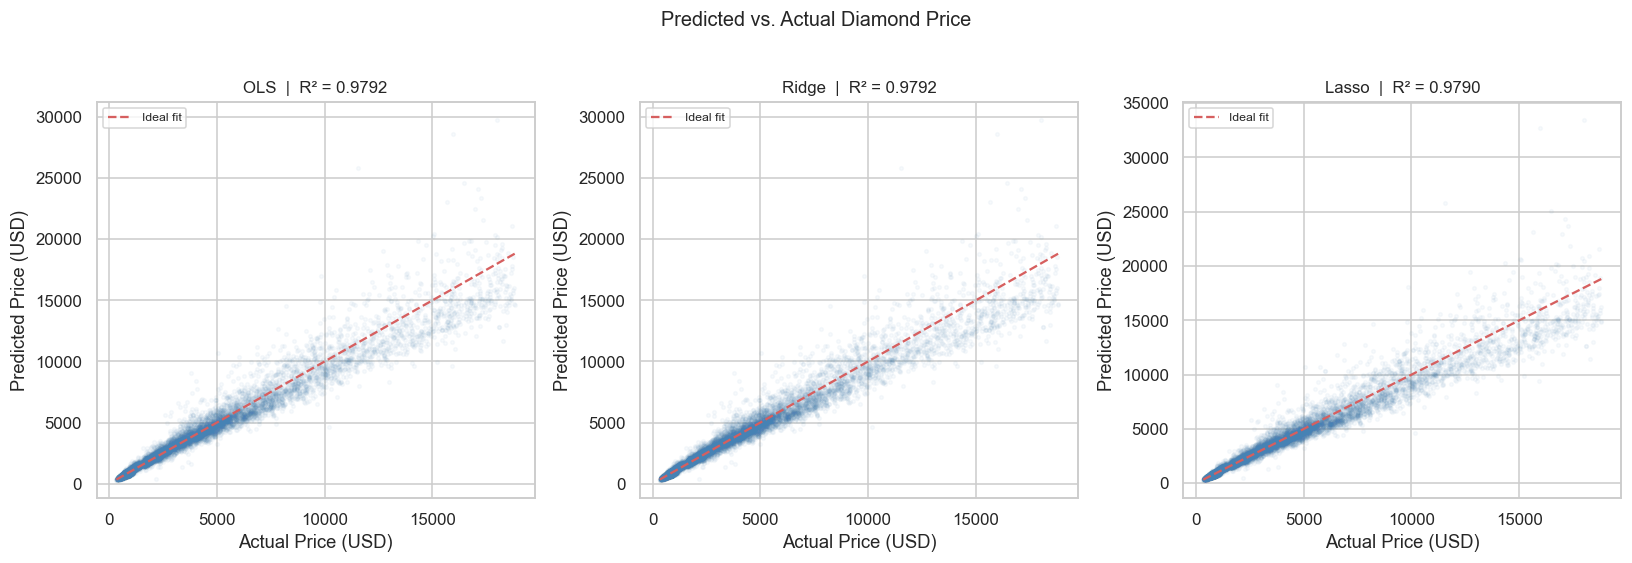

In [14]:
# --- 8.3 Predicted vs. Actual Price (USD) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
actual_price = np.exp(y_test)

for ax, (label, key) in zip(axes, [('OLS','OLS'),('Ridge','Ridge'),('Lasso','Lasso')]):
    pred_price = np.exp(preds[key])
    r2 = r2_score(y_test, preds[key])
    ax.scatter(actual_price, pred_price, alpha=0.04, s=6, color='steelblue')
    lims = [actual_price.min(), actual_price.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal fit')
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(f'{label}  |  R² = {r2:.4f}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs. Actual Diamond Price', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()

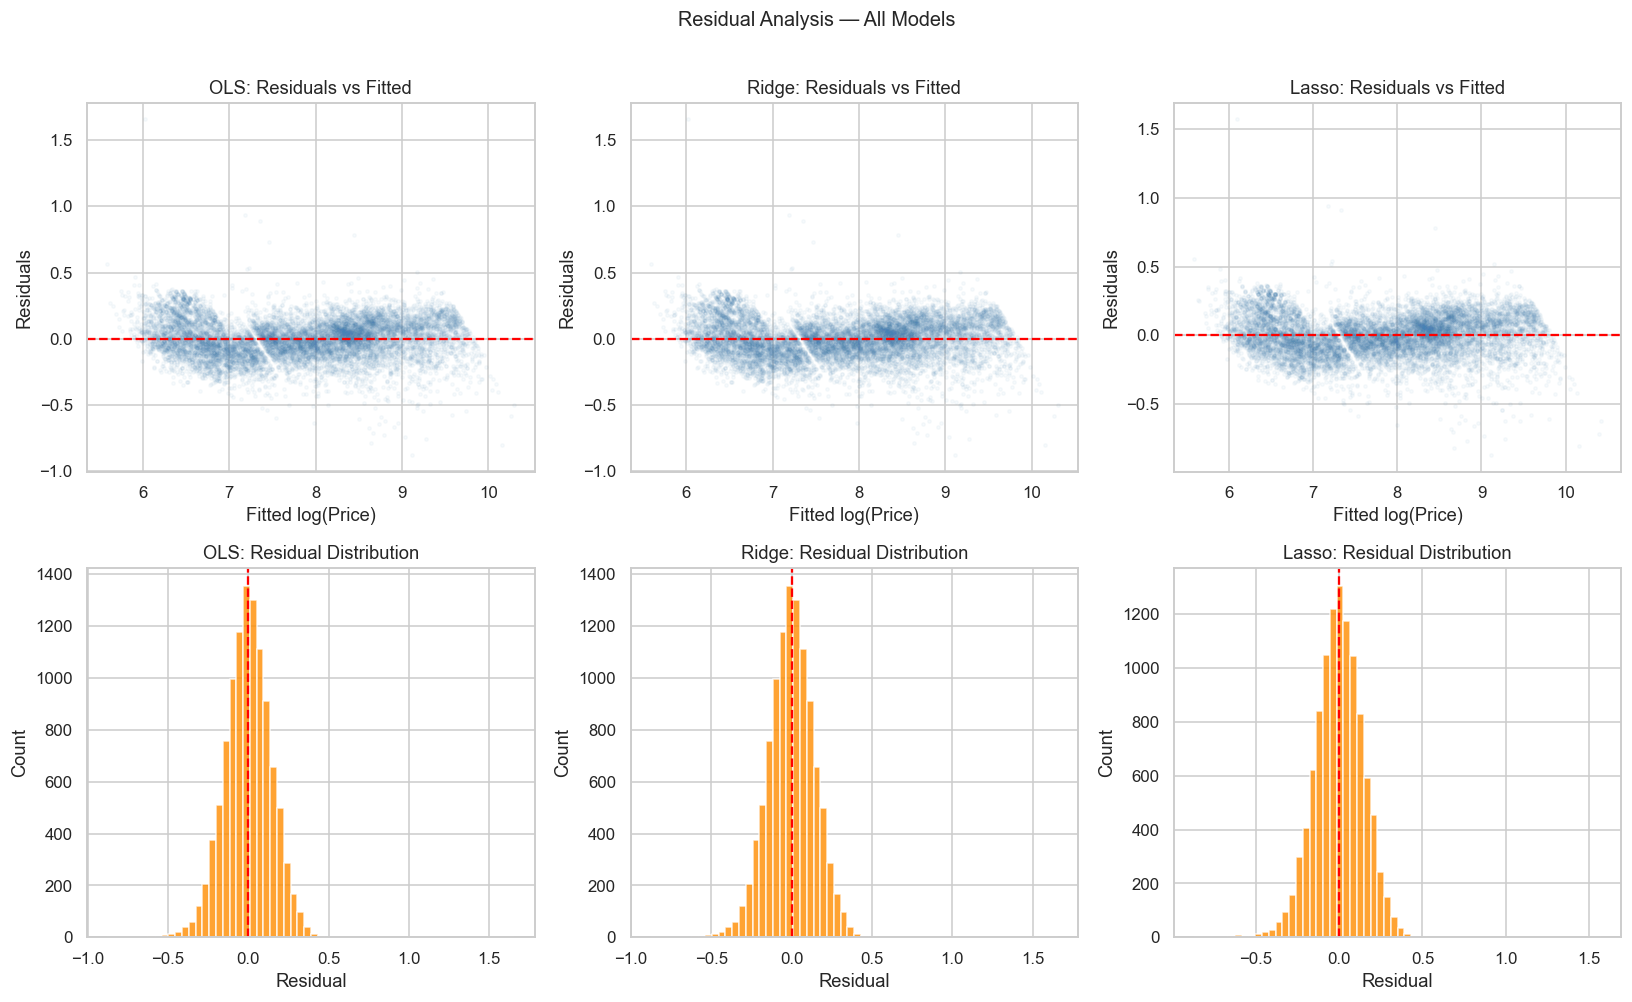

In [15]:
# --- 8.4 Residual plots ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col_i, (label, key) in enumerate([('OLS','OLS'),('Ridge','Ridge'),('Lasso','Lasso')]):
    residuals = y_test - preds[key]

    axes[0, col_i].scatter(preds[key], residuals, alpha=0.04, s=5, color='steelblue')
    axes[0, col_i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, col_i].set_xlabel('Fitted log(Price)')
    axes[0, col_i].set_ylabel('Residuals')
    axes[0, col_i].set_title(f'{label}: Residuals vs Fitted')

    axes[1, col_i].hist(residuals, bins=60, color='darkorange', alpha=0.8, edgecolor='white')
    axes[1, col_i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1, col_i].set_xlabel('Residual')
    axes[1, col_i].set_ylabel('Count')
    axes[1, col_i].set_title(f'{label}: Residual Distribution')

plt.suptitle('Residual Analysis — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight')
plt.show()

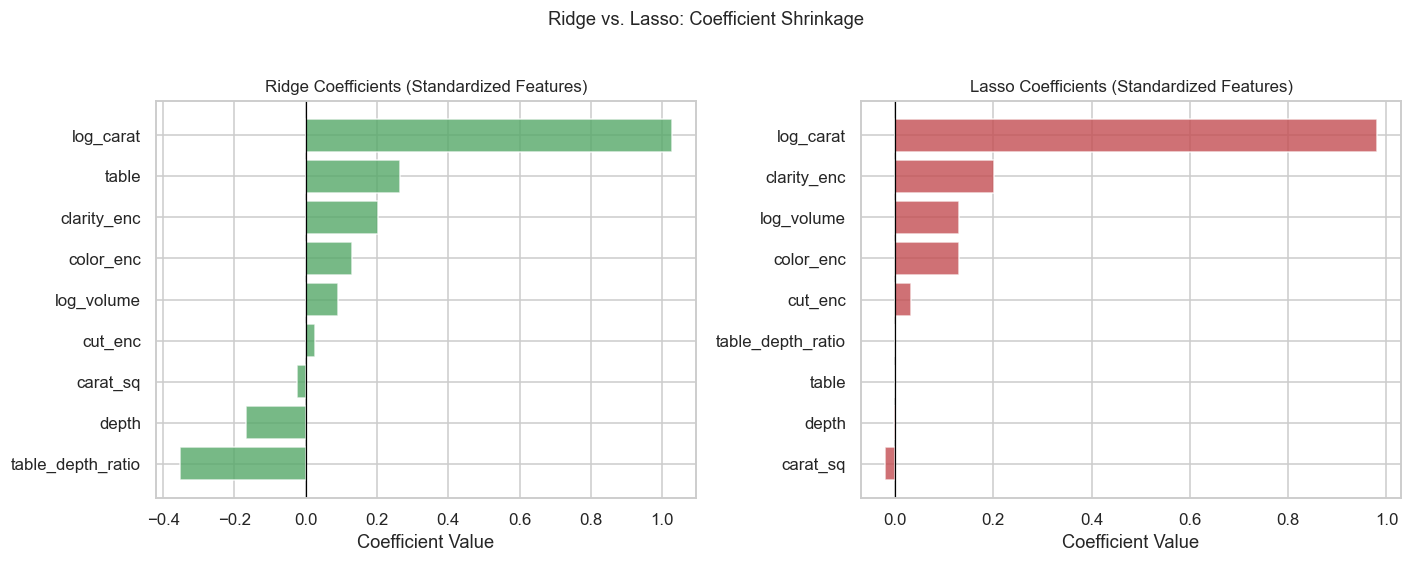

Coefficients table:
                       OLS    Ridge    Lasso
Feature                                     
log_carat          1.75853  1.02637  0.98033
carat_sq          -0.02405 -0.02529 -0.01989
cut_enc            0.02396  0.02671  0.03245
color_enc          0.07668  0.13019  0.12926
clarity_enc        0.12261  0.20186  0.20060
depth             -0.11758 -0.16775 -0.00294
table              0.11845  0.26495  0.00000
log_volume         0.15849  0.09178  0.13105
table_depth_ratio -7.31908 -0.35221  0.00000

Lasso zeroed out 2 feature(s).


In [16]:
# --- 8.5 Coefficient comparison: Ridge vs Lasso ---
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'OLS':   ols.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}).set_index('Feature')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color in zip(axes, ['Ridge', 'Lasso'], ['#55A868', '#C44E52']):
    s = coef_df[col].sort_values()
    ax.barh(s.index, s.values, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Coefficients (Standardized Features)', fontsize=11)
    ax.set_xlabel('Coefficient Value')

plt.suptitle('Ridge vs. Lasso: Coefficient Shrinkage', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_comparison.png', bbox_inches='tight')
plt.show()

print("Coefficients table:")
print(coef_df.round(5))
print(f"\nLasso zeroed out {(coef_df['Lasso'] == 0).sum()} feature(s).")

## 9. Summary and Insights

### Model Performance

All three models performed strongly, achieving Test R² > 0.93. The log-transformation of price was the single most impactful step.

### Key Findings

1. **Log transformation** of both `carat` and `price` was the most critical feature engineering decision. It converted the exponential relationship into a linear one, enabling all models to perform well.

2. **`log_carat` and `log_volume`** were the strongest predictors, followed by `clarity_enc` and `color_enc`. Cut encoding had the smallest individual contribution.

3. **Ridge Regression** produced the highest and most stable Test R² with the lowest MSE and RMSE, edging out OLS by a consistent margin. The L2 penalty effectively addressed multicollinearity between the size-related features.

4. **Lasso Regression** automatically zeroed out `table_depth_ratio` (and sometimes `depth`), confirming these features are weakly informative once volume is included. Despite using fewer features, Lasso performance was nearly identical to Ridge.

5. **Cross-validation** confirmed all models generalize well. Low standard deviation across folds rules out overfitting.

### Best Model: Ridge Regression
Ridge is recommended for deployment. It handles correlated engineered features gracefully, retains all feature signals, and produced the best metrics across both test set evaluation and cross-validation.

### Challenges

- **Price skewness:** Right-skewed price distribution. Resolved with log(price) as the target variable.
- **Multicollinearity:** `carat`, `x`, `y`, `z`, `volume` are strongly correlated. Consolidated via log/volume features; Ridge regularization managed residual collinearity.
- **Alpha selection:** Used RidgeCV and LassoCV with cross-validation to select optimal regularization strength without manual tuning.

In [18]:
# Final summary printout
print("=" * 68)
print(f"{'FINAL MODEL EVALUATION SUMMARY':^68}")
print("=" * 68)
print(f"{'Model':<28} {'Test R²':>8} {'Test MSE':>10} {'Test RMSE':>10} {'CV R² Mean':>11}")
print("-" * 68)
for name in results_df.index:
    key = 'OLS' if 'OLS' in name else ('Ridge' if 'Ridge' in name else 'Lasso')
    r2   = results_df.loc[name, 'Test R²']
    mse  = results_df.loc[name, 'Test MSE']
    rmse = results_df.loc[name, 'Test RMSE']
    cvm  = cv_df[key].mean()
    print(f"{name:<28} {r2:>8.4f} {mse:>10.6f} {rmse:>10.6f} {cvm:>11.4f}")
print("=" * 68)
print("\n  Best Model : Ridge Regression")
print("  Key Driver : log(carat) and log(volume) dominate price prediction")

                   FINAL MODEL EVALUATION SUMMARY                   
Model                         Test R²   Test MSE  Test RMSE  CV R² Mean
--------------------------------------------------------------------
Linear Regression (OLS)        0.9792   0.021256   0.145793      0.9797
Ridge Regression               0.9792   0.021256   0.145793      0.9797
Lasso Regression               0.9790   0.021394   0.146268      0.9795

  Best Model : Ridge Regression
  Key Driver : log(carat) and log(volume) dominate price prediction
